#  Title: Text-to-Music Emotion Alignment Framework
##  Author: Guanyi Yang （guanyiy）
##  Description:
A complete pipeline that predicts emotion from text using a pretrained Transformer model,  
maps emotion to a valence–energy space, compares it with Spotify audio features,  
computes alignment distances, ranks genres and songs, and visualizes the results.

In [1]:
# import libraries
from datasets import load_dataset
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F


# 1. Datasets (Spotify + emotion)
Load text emotion dataset and Spotify audio dataset.  
These form the input sources for emotion prediction and music comparison.

In [2]:
# load emotion dataset: https://huggingface.co/datasets/dair-ai/emotion
emotion_ds = load_dataset("dair-ai/emotion")
df_emotion = pd.DataFrame(emotion_ds["train"])
df_emotion.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [3]:
# Load Spotify Dataset: https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset
spotify_raw = load_dataset("maharshipandya/spotify-tracks-dataset", split="train")
spotify_df = pd.DataFrame(spotify_raw)

# Select relevant features
spotify_df = spotify_df[["track_name", "artists", "valence", "energy", "track_genre"]].dropna()

spotify_df.head()


,track_name,artists,valence,energy,track_genre
0,Comedy,Gen Hoshino,0.715,0.4610,acoustic
1,Ghost - Acoustic,Ben Woodward,0.267,0.1660,acoustic
2,To Begin Again,Ingrid Michaelson;ZAYN,0.120,0.3590,acoustic
3,Can't Help Falling In Love,Kina Grannis,0.143,0.0596,acoustic
4,Hold On,Chord Overstreet,0.167,0.4430,acoustic


# 2. Methodological Approach
## 2.1 Load emotion transformer model
Load a pretrained Transformer model (DistilBERT) to infer emotion from text.  
This provides the discrete emotion label used in later steps.


In [4]:
# Load Transformer Model for Emotion Prediction
model_name = "bhadresh-savani/distilbert-base-uncased-emotion"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

def predict_emotion(text):
    """
    Predict emotion label and confidence from raw text using DistilBERT.
    """
    inputs = tokenizer(text, return_tensors="pt", truncation=True)
    logits = model(**inputs).logits
    probs = F.softmax(logits, dim=1).detach().numpy()[0]

    idx = np.argmax(probs)
    label = model.config.id2label[idx]
    conf = probs[idx]

    return label, conf

# Test
predict_emotion("I feel so happy today!")

('joy', 0.99905354)

In [5]:
## Sample Emotion Predictions
sample_texts = [
    "I feel incredibly happy today!",
    "I am deeply sad and tired.",
    "Everything feels frightening and uncertain.",
    "I love spending time with my friends.",
    "I can't believe this happened!",
]

for t in sample_texts:
    emo, conf = predict_emotion(t)
    print(f"Text: {t}\n → Emotion: {emo} (confidence={conf:.2f})\n")

Text: I feel incredibly happy today!
 → Emotion: joy (confidence=1.00)

Text: I am deeply sad and tired.
 → Emotion: sadness (confidence=1.00)

Text: Everything feels frightening and uncertain.
 → Emotion: fear (confidence=0.99)

Text: I love spending time with my friends.
 → Emotion: joy (confidence=0.48)

Text: I can't believe this happened!
 → Emotion: joy (confidence=0.74)



## 2.2 Define emotion centroids
Map each discrete emotion to a valence–energy coordinate.
This enables comparison between text emotion and music audio features.


In [6]:
# Emotion → Valence–Energy Centroids
emotion_to_centroid = {
    "joy":      (0.85, 0.75),
    "love":     (0.75, 0.85),
    "surprise": (0.60, 0.60),
    "anger":    (0.20, 0.80),
    "fear":     (0.15, 0.70),
    "sadness":  (0.10, 0.30),
}

centroid_df = (
    pd.DataFrame(emotion_to_centroid).T
    .reset_index()
    .rename(columns={"index": "emotion", 0: "valence", 1: "energy"})
)

centroid_df

,emotion,valence,energy
0,joy,0.85,0.75
1,love,0.75,0.85
2,surprise,0.60,0.60
3,anger,0.20,0.80
4,fear,0.15,0.70
5,sadness,0.10,0.30


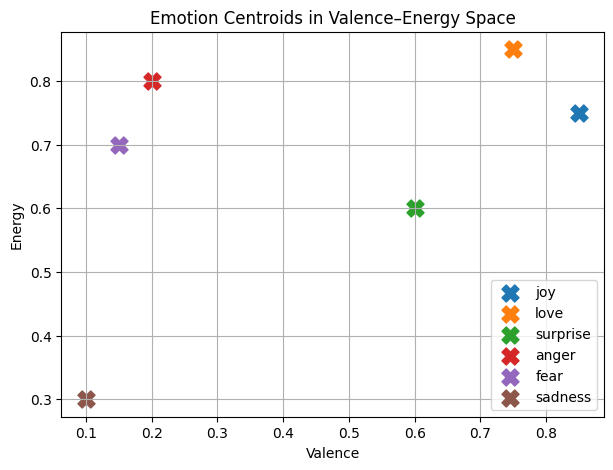

In [7]:
# Emotion Centroid Plot
def plot_centroids():
    plt.figure(figsize=(7,5))
    for emo, (v,e) in emotion_to_centroid.items():
        plt.scatter(v, e, s=150, marker="X", label=emo)

    plt.xlabel("Valence")
    plt.ylabel("Energy")
    plt.title("Emotion Centroids in Valence–Energy Space")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_centroids()

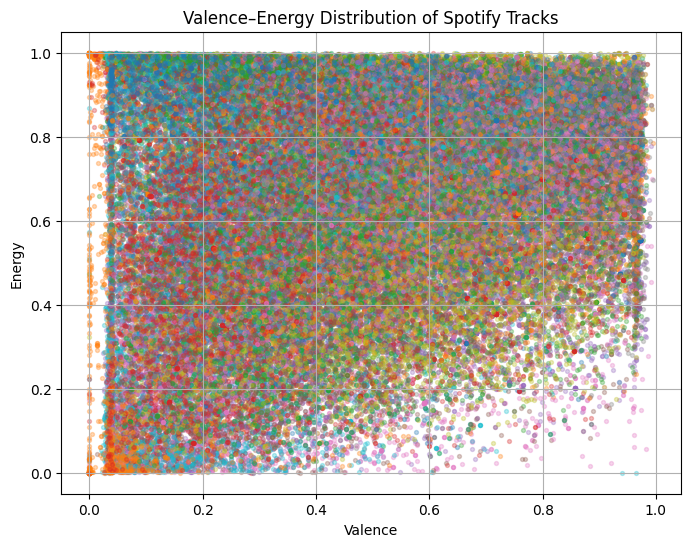

In [8]:
#  Spotify Valence–Energy Scatter Plot
plt.figure(figsize=(8, 6))
for genre, subset in spotify_df.groupby("track_genre"):
    plt.scatter(subset["valence"], subset["energy"], s=8, alpha=0.3)

plt.title("Valence–Energy Distribution of Spotify Tracks")
plt.xlabel("Valence")
plt.ylabel("Energy")
plt.grid(True)
plt.show()


## 2.3 Compute alignment distance
Measure how close a text emotion is to music tracks using Euclidean distance in the valence–energy space.

In [9]:
# Alignment Distance (Euclidean)
def alignment_distance(centroid, points):
    """
    Compute average Euclidean distance from centroid to a set of valence–energy points.
    """
    v0, e0 = centroid
    arr = points.values
    dist = np.sqrt((arr[:, 0] - v0) ** 2 + (arr[:, 1] - e0) ** 2)
    return dist.mean()

In [10]:
results = []
for emo, centroid in emotion_to_centroid.items():
    for genre, subset in spotify_df.groupby("track_genre"):
        dist = alignment_distance(centroid, subset[["valence", "energy"]])
        results.append([emo, genre, dist])

df_results = pd.DataFrame(results, columns=["emotion", "genre", "distance"])
df_results.head()

,emotion,genre,distance
0,joy,acoustic,0.572922
1,joy,afrobeat,0.258524
2,joy,alt-rock,0.389373
3,joy,alternative,0.415289
4,joy,ambient,0.873322


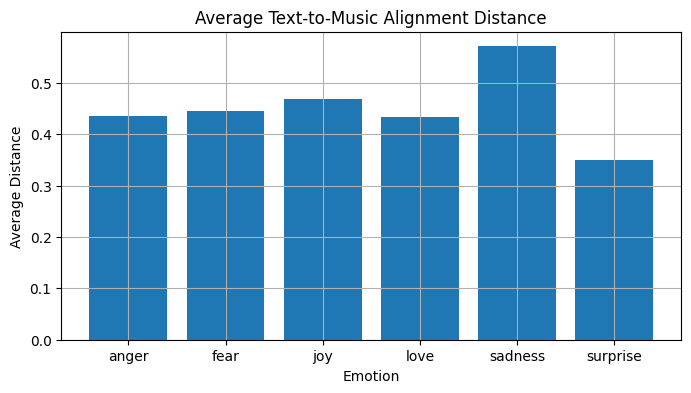

,emotion,distance
0,anger,0.435299
1,fear,0.446428
2,joy,0.468402
3,love,0.433845
4,sadness,0.571374
5,surprise,0.349559


In [11]:
# Average Alignment Distance per Emotion
df_avg = df_results.groupby("emotion")["distance"].mean().reset_index()

plt.figure(figsize=(8,4))
plt.bar(df_avg["emotion"], df_avg["distance"])
plt.title("Average Text-to-Music Alignment Distance")
plt.xlabel("Emotion")
plt.ylabel("Average Distance")
plt.grid(True)
plt.show()

df_avg


## 2.4 Rank genres and songs
Rank Spotify genres and individual songs based on emotional alignment.  
Lower distance = better emotional match.

In [12]:
# Ranking: Top Closest Genres
def get_top_genres(emotion_label, centroid, k=5):
    distances = []
    for genre, subset in spotify_df.groupby("track_genre"):
        ve = subset[["valence", "energy"]]
        d = alignment_distance(centroid, ve)
        distances.append((genre, d))

    return sorted(distances, key=lambda x: x[1])[:k]

for emo, centroid in emotion_to_centroid.items():
    print(f"\nEmotion: {emo}")
    for g, d in get_top_genres(emo, centroid):
        print(f"  {g:20s}  distance={d:.4f}")


Emotion: joy
  salsa                 distance=0.1750
  forro                 distance=0.2038
  pagode                distance=0.2277
  samba                 distance=0.2528
  afrobeat              distance=0.2585

Emotion: love
  forro                 distance=0.1952
  party                 distance=0.2071
  salsa                 distance=0.2185
  pagode                distance=0.2282
  reggaeton             distance=0.2302

Emotion: surprise
  dancehall             distance=0.2277
  pagode                distance=0.2374
  sertanejo             distance=0.2391
  funk                  distance=0.2404
  reggae                distance=0.2469

Emotion: anger
  black-metal           distance=0.2071
  dubstep               distance=0.2076
  death-metal           distance=0.2115
  trance                distance=0.2147
  grindcore             distance=0.2149

Emotion: fear
  dubstep               distance=0.2269
  minimal-techno        distance=0.2620
  black-metal           distance=0.2647
 

In [13]:
## 6. Ranking: Top Closest Songs

In [14]:
# Top Closest Songs per Emotion
def get_closest_songs(emotion_label, centroid, k=5):
    v0, e0 = centroid
    df = spotify_df.copy()
    df["dist"] = np.sqrt((df["valence"] - v0)**2 + (df["energy"] - e0)**2)
    return df.sort_values("dist")[["track_name", "artists", "track_genre", "dist"]].head(k)

for emo, centroid in emotion_to_centroid.items():
    print(f"\nEmotion: {emo}")
    display(get_closest_songs(emo, centroid))



Emotion: joy


,track_name,artists,track_genre,dist
95617,Lagrimas,Roberto Blades,salsa,0.001414
47529,Marvin - Ao vivo,Titãs,hard-rock,0.002236
37961,paixão vs amor,Bruno Gadiol,funk,0.003000
45838,Baila Cholita,William Luna,guitar,0.003000
57299,Uptight (Everything's Alright) - Single Version,Stevie Wonder,indie,0.003162



Emotion: love


,track_name,artists,track_genre,dist
38297,Descocada,Ultrasonicas,garage,0.001000
11390,Ticket To Ride - Remastered 2009,The Beatles,british,0.001000
63924,生きてく強さ,GLAY,j-rock,0.001000
84287,Ticket To Ride - Remastered 2009,The Beatles,psych-rock,0.001000
11528,I'll Be Waiting,Adele,british,0.002236



Emotion: surprise


...

,track_name,artists,track_genre,dist
104306,¿No Te Pasa?,ZPU,spanish,0.000000
109055,Aura,Avoure,techno,0.001414
39016,On Repeat,Robin Schulz;David Guetta,german,0.002236
53143,On Repeat,Robin Schulz;David Guetta,house,0.002236
53144,On Repeat,Robin Schulz;David Guetta,house,0.002236



Emotion: fear


,track_name,artists,track_genre,dist
85901,We'll Be a Dream (feat. Demi Lovato),We The Kings;Demi Lovato,punk-rock,0.002000
79558,We'll Be a Dream (feat. Demi Lovato),We The Kings;Demi Lovato,piano,0.002000
32570,Modern Love,Manuel Riva;IRAIDA,electronic,0.003162
43118,Modern Love,Manuel Riva;IRAIDA,groove,0.003162
72763,Constance,Spiritbox,metalcore,0.003162



Emotion: sadness


,track_name,artists,track_genre,dist
41909,Rivers,Epica,goth,0.002326
104875,Breogán,Mutenrohi,spanish,0.003523
93179,Sladka jagoda,Olga Voronets,romance,0.003606
12531,我為你狂,Agnes Chiang,cantopop,0.003606
79782,Blue & Grey - Midnight Edit,Smyang Piano,piano,0.004238


## 2.5 Gradio Demo
This interactive demo allows users to input text and receive the full emotion-to-music alignment results—emotion prediction, centroids, top genres, and recommended songs.


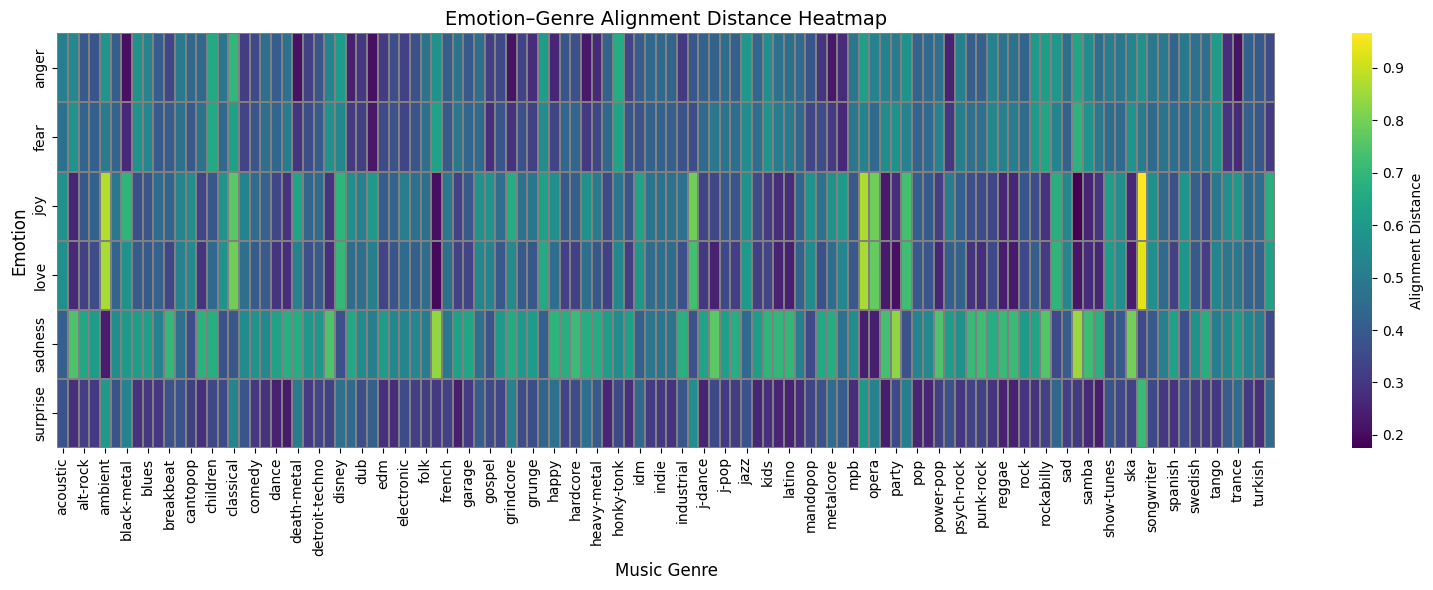

In [15]:
import seaborn as sns
# Pivot: emotions as rows, genres as columns
heatmap_df = df_results.pivot(index="emotion", columns="genre", values="distance")

plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_df,
    cmap="viridis",
    linewidths=0.3,
    linecolor="gray",
    cbar_kws={'label': 'Alignment Distance'},
)

plt.title("Emotion–Genre Alignment Distance Heatmap", fontsize=14)
plt.xlabel("Music Genre", fontsize=12)
plt.ylabel("Emotion", fontsize=12)
plt.tight_layout()

plt.show()

In [16]:
import gradio as gr
# Gradio Demo
def demo_predict(text):
    emo, conf = predict_emotion(text)
    centroid = emotion_to_centroid[emo]

    top_genres = get_top_genres(emo, centroid)
    top_songs = get_closest_songs(emo, centroid)

    return {
        "Predicted Emotion": emo,
        "Confidence": float(conf),
        "Centroid": centroid,
        "Top Genres": top_genres,
        "Top Songs": top_songs.to_dict(orient="records"),
    }

demo = gr.Interface(
    fn=demo_predict,
    inputs=gr.Textbox(label="Enter text"),
    outputs="json",
    title="Text-to-Music Emotion Alignment Demo"
)

demo.launch()


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
